# 📘Домашнє завдання №9 Описовий аналіз даних (Exploratory Data Analysis)

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW9

Використати вбудований датасет:

In [1]:
# Download data (to cover the case when the data aren't accessible)

# !pip install --upgrade nbformat
# !pip install jinja2

import shutil
import sqlite3
import pandas as pd
import seaborn as sns
from pathlib import Path

from IPython.core.display import Markdown
from IPython.display import display

# Input data
ds_name = "iris"
db_file_name = "store_hw9.db"
git_project_url = "https://github.com/BogdanPinchuk/DataScience-PBY_HW9.git"
main_file_name = "Bohdan_Pinchuk_DS_HW9.ipynb"

# Solution

# Note: to handle error: "SSL: CERTIFICATE_VERIFY_FAILED" or no connection to the server
try:
    # for testing
    # raise Exception
    ds_data = sns.load_dataset(ds_name)

    # Use only one time to initialize/update data (at first time)
    # conn = sqlite3.connect(db_file_name)
    # ds_data.to_sql(ds_name, conn, if_exists="replace", index=False)
    # conn.close()
except Exception:
    file_path = Path(db_file_name)

    if not file_path.exists():
        # upload all files
        current_path = !pwd
        current_path = current_path[0]
        parent_path = !dirname "$current_path"
        parent_path = parent_path[0]
        temp_path = f"{parent_path}/temp"

        # Clone data
        !rm -rf "$temp_path"
        !git clone "$git_project_url" "$temp_path"

        source = Path(temp_path)
        destination = Path(current_path)
        exclude = {main_file_name, ".git", ".idea"}

        for item in source.iterdir():
            if item.name in exclude:
                continue

            target = destination / item.name
            if item.is_dir():
                shutil.copytree(item, target, dirs_exist_ok=True)
            else:
                shutil.copy2(item, target)

        # Clean temp folder
        !rm -rf "$temp_path"

    conn = sqlite3.connect(db_file_name)
    ds_data = pd.read_sql(f"SELECT * FROM {ds_name}", conn)
    conn.close()

# display(ds_data)

In [2]:
## Отримання даних

# Solution
iris = ds_data.copy()

# Print results
display(iris)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Датасет дані про квіти ірисів трьох видів:
* Setosa
* Versicolor
* Virginica

Для кожної квітки виміряно 4 числові характеристики:
* `sepal_length` — довжина чашолистка
* `sepal_width` — ширина чашолистка
* `petal_length` — довжина пелюстки
* `petal_width` — ширина пелюстки

Цільова змінна:
* `species` — вид квітки (категоріальна змінна)

# Завдання (за етапами EDA)
1. Ознайомлення з даними
* Вивести перші 5 рядків
* Визначити:
  * кількість рядків і стовпців
  * назви колонок
  * типи даних
* Питання:
  * Скільки об’єктів у датасеті?
  * Скільки ознак?
2. Розуміння змінних
* Визначити:
  * числові змінні
  * категоріальні змінні
  * Визначити "цільову змінну"
* Питання:
  * Яка змінна є цільовою?
  * Які змінні описують об’єкти?
3. Перевірка пропущених значень
* Перевірити наявність пропусків
* Питання:
  * Чи є пропущені значення?
  * Якщо є — що з ними робити?
4. Описова статистика
* Вивести статистику для числових змінних
* Питання:
  * Яка ознака має найбільше середнє значення?
  * Чи є сильні відмінності між ознаками?
5. Аналіз категоріальних змінних
* Визначити кількість об’єктів кожного класу
* Питання:
  * Чи збалансований датасет (чи класи розподілені приблизно порівну)?
6. Аналіз розподілів
* Побудувати гістограми для всіх числових змінних
* Побудувати boxplot
* Питання:
  * Чи є викиди?
  * Які розподіли (симетричні чи ні)?
7. Аналіз цільової змінної
* Візуалізувати розподіл класів
* Питання:
  * Який клас найчастіший?
8. Біваріантний аналіз
* Побудувати:
  * scatterplot між ознаками
  * boxplot (ознака vs клас)
* Питання:
  * Які ознаки найкраще розділяють класи?
9. Кореляційний аналіз
* Побудувати кореляційну матрицю
* Питання:
  * Які змінні сильно корелюють?
  * Чи є надлишкові ознаки?
10. Зведені таблиці (Pivot Tables)
* Побудувати середні значення ознак по класах
* Питання:
  * Як відрізняються класи між собою?
11. Виявлення закономірностей
* Описати:
  * які ознаки найважливіші
  * як відрізняються класи
12. Висновки
* Написати висновки:
  * про структуру даних
  * про залежності

In [3]:
# 1. Ознайомлення з даними

import numpy as np
import pandas as pd

# Input data
n_first_rows = 5

# Solution
display(Markdown(f"""
### 1. Ознайомлення з даними
"""))

display(Markdown(f"""
---
Виведення перших {n_first_rows} рядків:
"""), iris.head(n_first_rows))

n_columns = iris.columns.size
n_rows = iris.index.size
columns_df = pd.DataFrame(iris.columns, columns=["Columns"])
types_df = pd.DataFrame(iris.dtypes, columns=["Types"])

display(Markdown(f"""
---
Параметри таблиці:
* Кількість рядків: **{iris.index.size}**
* Кількість стовпців: **{iris.columns.size}**
"""))

display(Markdown(f"""
* Назви колонок:
"""), columns_df.style.hide(axis='index'))

display(Markdown(f"""
* Типи даних:
"""), types_df)

col_num_type = iris.select_dtypes(include=np.number).columns
col_cat_type = iris.select_dtypes(exclude=np.number).columns

display(Markdown(f"""
---
Відповіді:
* Кількість об’єктів у датасеті: **{iris.index.size}**
* Кількість числових ознак: **{col_num_type.size}**
* Кількість категоріальних ознак: **{col_cat_type.size}**
---
"""))


### 1. Ознайомлення з даними



---
Виведення перших 5 рядків:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



---
Параметри таблиці:
* Кількість рядків: **150**
* Кількість стовпців: **5**



* Назви колонок:


Columns
sepal_length
sepal_width
petal_length
petal_width
species



* Типи даних:


,Types
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,str



---
Відповіді:
* Кількість об’єктів у датасеті: **150**
* Кількість числових ознак: **4**
* Кількість категоріальних ознак: **1**
---


In [4]:
# 2. Розуміння змінних

import pandas as pd

# Input data

# Solution
col_num_type_df = pd.DataFrame(col_num_type, columns=["Numeric variables"])
col_cat_type_df = pd.DataFrame(col_cat_type, columns=["Categorical variables"])

display(Markdown(f"""
### 2. Розуміння змінних
"""))

display(Markdown(f"""
---
Визначення:
* Числові змінні:
"""), col_num_type_df.style.hide(axis='index'))

cat_types = iris.select_dtypes(exclude=['str']).columns
col_targ_type_df = pd.DataFrame(col_cat_type, columns=["Target variables"])

display(Markdown(f"""
* Категоріальні змінні:
"""), col_cat_type_df.style.hide(axis='index'))

display(Markdown(f"""
* Цільова зміна:
"""), col_targ_type_df.style.hide(axis='index'))

display(Markdown(f"""
**Примітка**

> Числові змінні - це змінні, які відображають характеристики обʼєкта, його результати, величину впливу на нього тощо. Аналогія: поля ініціалізованого об'єкта.

> Категоріальні змінні - це змінні, що описують обʼєкт відносячи його до певної групи, або ж це групи, поділені за певними діапазонами ознак. Аналогії: 1. бази даних SQL, в якій дочірня таблиця містить у собі зовнішній ключ (подібно до назви групи) і використовується в мастер-таблиці. 2. Enum (типи значень в Java, C#), які несуть у собі певне пояснення у відмінності, або ж як interface (інтерфейс в Java, C#) або абстрактний клас в Python, де при наслідуванні клас наслідує поведінку та деякі характеристики, якщо це передбачено.

> Цільові змінні - це змінні, які описують очікуваний вихідний/прогнозований результат залежно від ознак, тобто назва групи/категорії. Якщо обрати одну з категоріальних змінних і розглянути саме її структуру, то в цьому об'єктові представлення/назва/мітка/ID і буде цільовою змінною. Аналогія: клас ініціалізованого обʼєкта з усіма необхідними полями та наслідуванням від необхідних абстрактних класів.

> Структура: вхідні параметри — це числові й категоріальні змінні, а вихідний результат - цільова змінна. Наприклад: ```def function(*числові та категоріальні змінні) -> (цільові змінні):```
"""))

display(Markdown(f"""
---
Відповіді:
* Цільовою змінною є: _**{', '.join(col_targ_type_df['Target variables'].astype(str))}**_
* Змінними, які описують обʼєкт є: _**{', '.join(col_num_type_df['Numeric variables'].astype(str))}**_
---
"""))


### 2. Розуміння змінних



---
Визначення:
* Числові змінні:


Numeric variables
sepal_length
sepal_width
petal_length
petal_width



* Категоріальні змінні:


Categorical variables
species



* Цільова зміна:


Target variables
species



**Примітка**

> Числові змінні - це змінні, які відображають характеристики обʼєкта, його результати, величину впливу на нього тощо. Аналогія: поля ініціалізованого об'єкта.

> Категоріальні змінні - це змінні, що описують обʼєкт відносячи його до певної групи, або ж це групи, поділені за певними діапазонами ознак. Аналогії: 1. бази даних SQL, в якій дочірня таблиця містить у собі зовнішній ключ (подібно до назви групи) і використовується в мастер-таблиці. 2. Enum (типи значень в Java, C#), які несуть у собі певне пояснення у відмінності, або ж як interface (інтерфейс в Java, C#) або абстрактний клас в Python, де при наслідуванні клас наслідує поведінку та деякі характеристики, якщо це передбачено.

> Цільові змінні - це змінні, які описують очікуваний вихідний/прогнозований результат залежно від ознак, тобто назва групи/категорії. Якщо обрати одну з категоріальних змінних і розглянути саме її структуру, то в цьому об'єктові представлення/назва/мітка/ID і буде цільовою змінною. Аналогія: клас ініціалізованого обʼєкта з усіма необхідними полями та наслідуванням від необхідних абстрактних класів.

> Структура: вхідні параметри — це числові й категоріальні змінні, а вихідний результат - цільова змінна. Наприклад: ```def function(*числові та категоріальні змінні) -> (цільові змінні):```



---
Відповіді:
* Цільовою змінною є: _**species**_
* Змінними, які описують обʼєкт є: _**sepal_length, sepal_width, petal_length, petal_width**_
---


In [5]:
# 3. Перевірка пропущених значень

# Input data

# Solution
empty_val_by_col = iris.isnull().sum().to_frame(name='Count')

display(Markdown(f"""
### 3. Перевірка пропущених значень
"""))

display(Markdown(f"""
---
Наявність пропусків:
* Пропуски в кожній колонці:
"""), empty_val_by_col)

is_empty_val = empty_val_by_col.values.sum() > 0

display(Markdown(f"""
---
Відповіді:
* Пропущені значення: _**{'є' if is_empty_val > 0 else 'немає'}**_
* Обробка пропущених значень: _На мою думку, пропущенні значення опрацьовуються залежно від їх цінності. Якщо обʼєктів у достатній кількості, а пропущених значень доволі мало та вимагається просто проглянути загальну картину без подальшого їх використання, то достатньо просто вилучити ці значення із таблиці ```dropna()```. Якщо ж обʼєктів мало, або якщо вони є критичними, тоді можна проаналізувати ознаку цієї колонки, якщо вона не є критичною і в цій колонці значна частина має пропуски, то замість видалення обʼєктів можна вилучити цю колонку ```drop(columns=['col_1',..., 'col_n'])```. Якщо ж сам обʼєкт загалом має багато пропусків, особливо по критичних ознаках, а також щоб він не вносив "шуму" в аналіз даних, то можна вилучити саме цей обʼєкт базуючись на критичних колонках ```dropna(subset=['col_1',..., 'col_n'])``` або на мінімальній кількості заповнених ознак ```dropna(thresh=n_existed_values)```. Якщо ж нвм критично необхідно заповнити декілька значень, то залежно від типу ознаки її смислу можна скористатися модою (найбільша частота), медіаною (центральне значення у відсортованому списку), середнім значенням (математичне очікування) тощо._
---
"""))



### 3. Перевірка пропущених значень



---
Наявність пропусків:
* Пропуски в кожній колонці:


,Count
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0



---
Відповіді:
* Пропущені значення: _**немає**_
* Обробка пропущених значень: _На мою думку, пропущенні значення опрацьовуються залежно від їх цінності. Якщо обʼєктів у достатній кількості, а пропущених значень доволі мало та вимагається просто проглянути загальну картину без подальшого їх використання, то достатньо просто вилучити ці значення із таблиці ```dropna()```. Якщо ж обʼєктів мало, або якщо вони є критичними, тоді можна проаналізувати ознаку цієї колонки, якщо вона не є критичною і в цій колонці значна частина має пропуски, то замість видалення обʼєктів можна вилучити цю колонку ```drop(columns=['col_1',..., 'col_n'])```. Якщо ж сам обʼєкт загалом має багато пропусків, особливо по критичних ознаках, а також щоб він не вносив "шуму" в аналіз даних, то можна вилучити саме цей обʼєкт базуючись на критичних колонках ```dropna(subset=['col_1',..., 'col_n'])``` або на мінімальній кількості заповнених ознак ```dropna(thresh=n_existed_values)```. Якщо ж нвм критично необхідно заповнити декілька значень, то залежно від типу ознаки її смислу можна скористатися модою (найбільша частота), медіаною (центральне значення у відсортованому списку), середнім значенням (математичне очікування) тощо._
---


In [6]:
# 4. Описова статистика

import numpy as np

# Input data
contrast_level = 0.25
# Note. The value is only for example

# Solution
data_num_type_df = iris.select_dtypes(include=np.number)
data_cat_type_df = iris.select_dtypes(exclude=np.number)

display(Markdown(f"""
### 4. Описова статистика
"""))

target_value = col_targ_type_df['Target variables'].iloc[0]

display(Markdown(f"""
---
* Статистика для числових змінних:
"""), data_num_type_df.describe().T.style.set_caption("Totally"),
        iris.groupby([target_value]).describe().T.stack().unstack(level=1).style.set_caption("By category"))

display(Markdown(f"""
* Статистика для категоріальних змінних:
"""), data_cat_type_df.describe().T.style.set_caption("Totally"))


# Note. I used the "optical" contrast definition
def contrast(val1: np.number, val2: np.number) -> float:
    """
    Contrast between 2 values
    :param val1: first value
    :param val2: second value
    :return: result between 0 and 1
    """
    return abs(val1 - val2) / abs(val1 + val2) if (val1 + val2) != 0 else 0


sorted_data_num_type_df = data_num_type_df.mean().sort_values()
max_contrast = max([contrast(sorted_data_num_type_df.iloc[i], sorted_data_num_type_df.iloc[i + 1])
                    for i in range(len(sorted_data_num_type_df) - 1)])

display(Markdown(f"""
---
Відповіді:
* Ознака з найбільшим середнім значенням: _**{data_num_type_df.mean().idxmax()}**_
* Оцінка відмінностей:
\n\tРівень відмінності між ознаками, при якому він буде вважатиметься сильним: _**{contrast_level:.2%}**_
\n\tСильні відмінності між ознаками (за дисперсією): _**{'є' if max_contrast >= contrast_level else 'немає'}**_
\n\tМаксимальна відмінність між ознаками (упорядкованими за дисперсією): _**{max_contrast:.2%}**_
\n\tОзнака з найбільшою дисперсією (розкидом значень): _**{data_num_type_df.std().idxmax()}**_
---
"""))



### 4. Описова статистика



---
* Статистика для числових змінних:


,count,mean,std,min,25%,50%,75%,max
sepal_length,150.000000,5.843333,0.828066,4.300000,5.100000,5.800000,6.400000,7.900000
sepal_width,150.000000,3.057333,0.435866,2.000000,2.800000,3.000000,3.300000,4.400000
petal_length,150.000000,3.758000,1.765298,1.000000,1.600000,4.350000,5.100000,6.900000
petal_width,150.000000,1.199333,0.762238,0.100000,0.300000,1.300000,1.800000,2.500000



* Статистика для категоріальних змінних:


,count,unique,top,freq
species,150,3,setosa,50



---
Відповіді:
* Ознака з найбільшим середнім значенням: _**sepal_length**_
* Оцінка відмінностей:

	Рівень відмінності між ознаками, при якому він буде вважатиметься сильним: _**25.00%**_

	Сильні відмінності між ознаками (за дисперсією): _**є**_

	Максимальна відмінність між ознаками (упорядкованими за дисперсією): _**43.65%**_

	Ознака з найбільшою дисперсією (розкидом значень): _**petal_length**_
---


In [7]:
# 5. Аналіз категоріальних змінних

# Input data
balans_level = 0.1
# Note. The value is only for example

# Solution
display(Markdown(f"""
### 5. Аналіз категоріальних змінних
"""))

display(Markdown(f"""
---
* Кількість об’єктів кожного класу:
"""), iris[target_value].value_counts().to_frame(name="Count"))

sorted_class_count = iris[target_value].value_counts().tolist()
max_contrast = contrast(min(sorted_class_count), max(sorted_class_count))

display(Markdown(f"""
---
Відповіді:
* Рівень датасету, при якому він буде вважатиметься збалансованим: _**{balans_level:.2%}**_
* Датасет збалансований: _**{'так' if max_contrast <= balans_level else 'ні'}**_
* Максимальна відмінність між класами: _**{max_contrast:.2%}**_
---
"""))



### 5. Аналіз категоріальних змінних



---
* Кількість об’єктів кожного класу:


,Count
species,
setosa,50
versicolor,50
virginica,50



---
Відповіді:
* Рівень датасету, при якому він буде вважатиметься збалансованим: _**10.00%**_
* Датасет збалансований: _**так**_
* Максимальна відмінність між класами: _**0.00%**_
---


In [8]:
# 6. Аналіз розподілів

import numpy as np
from scipy.stats import gaussian_kde

# Input data
smoothing = 0.25
n_points = 100

# Solution
x_array = []
y_array = []
mean_array = []

x_left_array = []
y_left_array = []
x_right_array = []
y_right_array = []

for col_name in data_num_type_df.columns:
    col_data = data_num_type_df[col_name].values
    mean_val = col_data.mean()
    mean_array.append(mean_val)

    density_data = gaussian_kde(col_data, bw_method=smoothing)
    x_data = np.linspace(col_data.min(), col_data.max(), n_points)
    x_array.append(x_data)
    y_data = density_data.evaluate(x_data)
    y_array.append(y_data)

    x_left = x_data[x_data <= mean_val]
    x_right = x_data[len(x_left):]
    y_left = y_data[0:len(x_left)]
    y_right = y_data[len(x_left):]
    x_left_array.append(x_left)
    x_right_array.append(x_right)
    y_left_array.append(y_left)
    y_right_array.append(y_right)

# display(Markdown(f"""
# ### 6. Аналіз розподілів
# """))
#
# display(Markdown(f"""
# ---
# Відповіді:
# * Викиди/outliers (по boxplot):
# \n\t- "sepal_length": відсутні викиди;
# \n\t- "sepal_width": помітні викиди;
# \n\t- "petal_length": відсутні викиди, але доволі великий розкид значень;
# \n\t- "petal_width": відсутні викиди;
# * Симетричність (по гістограмах):
# \n\t- "sepal_length": доволі симетричний;
# \n\t- "sepal_width": симетричний;
# \n\t- "petal_length": несиметричний і бімодальний;
# \n\t- "petal_width": несиметричний;
# ---
# """))

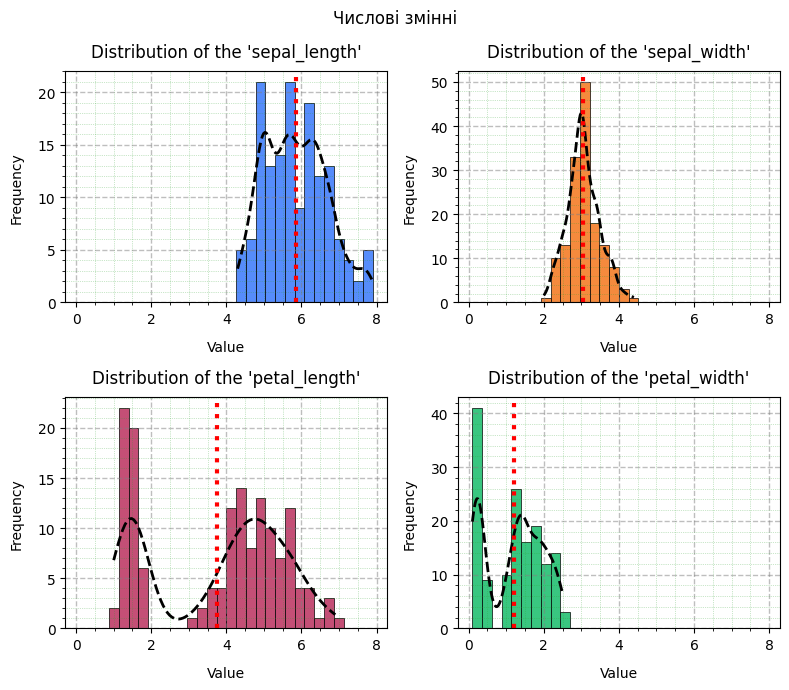

In [9]:
# Graphic results - Histograms

import matplotlib.pyplot as plt

# Input data
n_bins = 30
n_columns = 2

# Solution
axes = data_num_type_df.plot.hist(subplots=True, layout=(-1, n_columns), figsize=(8, 7),
                                  bins=n_bins, edgecolor="black", linewidth=0.5, sharex=False, sharey=False)

for i, ax in enumerate(axes.flatten()):
    legend_text = ax.get_legend().get_texts()[0].get_text()
    bin_width = ax.patches[0].get_width()
    counts = data_num_type_df[legend_text].count()
    scale_coef = bin_width * counts
    ax.plot(x_array[i], y_array[i] * scale_coef, color='black', linestyle='dashed', linewidth=2.0)

    ax.axvline(float(mean_array[i]), linestyle=':', color='red', linewidth=3.0)

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(f"Distribution of the '{legend_text}'", pad=10, loc='center', color='black')
    ax.set_xlabel("Value", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Frequency", labelpad=10, loc='center', color='black')
    ax.get_legend().set_visible(False)

plt.suptitle("Числові змінні")

plt.tight_layout()
plt.show()

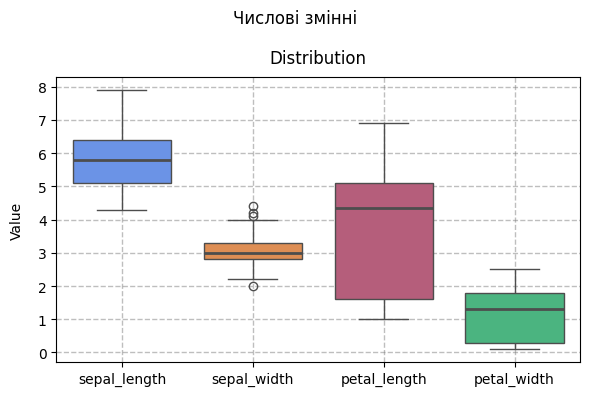

In [10]:
# Graphic results - Box Plot

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(data_num_type_df, ax=ax, width=0.75, medianprops={'linewidth': 2.0})

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_ylabel("Value", labelpad=10, loc='center', color='black')

plt.suptitle("Числові змінні")

plt.tight_layout()
plt.show()

In [11]:
# 7. Аналіз цільової змінної


# Input data

# Solution


display(Markdown(f"""
### 7. Аналіз цільової змінної
"""))

display(Markdown(f"""
---
Відповіді:
* Викиди/outliers (по boxplot):
* Симетричність (по гістограмах):
---
"""))



### 7. Аналіз цільової змінної



---
Відповіді:
* Викиди/outliers (по boxplot):
* Симетричність (по гістограмах):
---


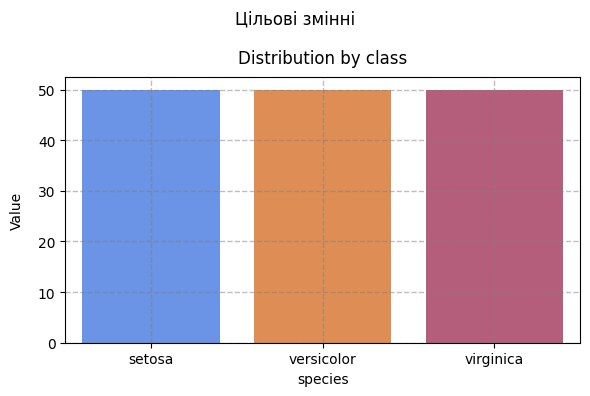

In [12]:
# Graphic results - Box Plot

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(6, 4))

sns.countplot(data=data_cat_type_df, ax=ax, x=target_value, hue=target_value)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Distribution by class", pad=10, loc='center', color='black')
ax.set_ylabel("Value", labelpad=10, loc='center', color='black')

plt.suptitle("Цільові змінні")

plt.tight_layout()
plt.show()